In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import ast
#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

reviews = pd.read_csv("../../../../data/preprocessed/steam_indie_reviews.csv")

reviews

,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,author_steamid,author_num_games_owned,author_num_reviews,author_last_played,created_date,updated_date,author_last_played_date,playtime_forever_hours,playtime_last_two_weeks_hours,playtime_at_review_hours
0,18074882,402160,english,"Right, \n\nSo it's finally here. I've been fol...",1442518373,1442518373,True,28,1,0.566620,...,76561198165054946,192,10,1498410553,2015-09-17 19:32:53,2015-09-17 19:32:53,2017-06-25 17:09:13,2.600000,0.000000,1.016667
1,18087211,402160,french,"Que de progres avec l alpha 8, le jeu est plus...",1442599803,1456696995,True,0,0,0.500000,...,76561198006977426,0,203,1557324364,2015-09-18 18:10:03,2016-02-28 22:03:15,2019-05-08 14:06:04,6.583333,0.000000,3.916667
2,18088231,402160,english,It was very difficult to play through the tuto...,1442604265,1442619282,False,36,1,0.549283,...,76561197985210015,637,10,1442604225,2015-09-18 19:24:25,2015-09-18 23:34:42,2015-09-18 19:23:45,0.716667,0.000000,0.716667
3,18090086,402160,english,This game has so much potential. I have been f...,1442612819,1442612819,True,3,0,0.459119,...,76561198157280135,0,3,1538952557,2015-09-18 21:46:59,2015-09-18 21:46:59,2018-10-07 22:49:17,8.000000,0.000000,3.050000
4,18091821,402160,english,I'm recommending this game because of what I'v...,1442623099,1442623099,True,4,0,0.445526,...,76561197961599249,0,23,1474237215,2015-09-19 00:38:19,2015-09-19 00:38:19,2016-09-18 22:20:15,1.400000,0.000000,0.366667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235848,222282640,3570430,english,"Movement feels clunky even after 2 hours of ""g...",1775079450,1775079450,False,5,0,0.557372,...,76561198141967531,508,278,1775079323,2026-04-01 21:37:30,2026-04-01 21:37:30,2026-04-01 21:35:23,2.166667,0.000000,2.166667
235849,222568873,3570430,english,>Notice I can buy the suspiciously expensive u...,1775383883,1775383883,False,1,0,0.456982,...,76561198026906699,614,8,1775381677,2026-04-05 10:11:23,2026-04-05 10:11:23,2026-04-05 09:34:37,5.050000,0.000000,5.050000
235850,222951359,3570430,english,very fun the first time around but those missa...,1775835580,1775835580,True,0,0,0.500000,...,76561198065571122,175,12,1775835487,2026-04-10 15:39:40,2026-04-10 15:39:40,2026-04-10 15:38:07,15.916667,0.000000,15.916667
235851,223358991,3570430,schinese,You really should add a refund function for th...,1776327633,1776327633,True,0,0,0.500000,...,76561199438953171,649,37,1776688506,2026-04-16 08:20:33,2026-04-16 08:20:33,2026-04-20 12:35:06,12.133333,9.116667,4.600000


In [66]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,235843,235844,235845,235846,235847,235848,235849,235850,235851,235852
recommendationid,18074882,18087211,18088231,18090086,18091821,18093415,18098561,18108541,18109316,18112699,...,220554159,220690775,220776638,221264498,222257060,222282640,222568873,222951359,223358991,223599892
appid,402160,402160,402160,402160,402160,402160,402160,402160,402160,402160,...,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430
language,english,french,english,english,english,english,italian,english,german,russian,...,english,japanese,english,german,english,english,english,english,schinese,english
review,"Right, \n\nSo it's finally here. I've been fol...","Que de progres avec l alpha 8, le jeu est plus...",It was very difficult to play through the tuto...,This game has so much potential. I have been f...,I'm recommending this game because of what I'v...,This is an exceptional bit of fun. Be warned ...,"Il gioco sembra promettere bene, non aspettate...","Game crashes 75% of the time, labels are all w...",zu dem game gibt es nur eins zu sagen...\ndas ...,"The game is broken for now, there must be terr...",...,Eventually gets completely unreasonably grindy,いやー面白かった\n一般的なスネークゲーム＋最近流行りのローグライクインクリメンタルゲーム\...,Not bad.,Good Game,Excellent incremental game if you enjoy playin...,"Movement feels clunky even after 2 hours of ""g...",>Notice I can buy the suspiciously expensive u...,very fun the first time around but those missa...,You really should add a refund function for th...,This game was so monotonous it made me questio...
timestamp_created,1442518373,1442599803,1442604265,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775055895,1775079450,1775383883,1775835580,1776327633,1776582674
timestamp_updated,1442518373,1456696995,1442619282,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775237034,1775079450,1775383883,1775835580,1776327633,1776582674
voted_up,True,True,False,True,True,True,True,False,False,False,...,False,True,True,True,True,False,False,True,True,True
votes_up,28,0,36,3,4,51,2,14,1,4,...,2,0,0,0,0,5,1,0,0,0
votes_funny,1,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.56662,0.5,0.549283,0.459119,0.445526,0.633423,0.491556,0.483005,0.437055,0.463736,...,0.547325,0.5,0.5,0.5,0.5,0.557372,0.456982,0.5,0.5,0.5


In [67]:
reviews.isna().sum()

recommendationid                 0
appid                            0
language                         0
review                           0
timestamp_created                0
timestamp_updated                0
voted_up                         0
votes_up                         0
votes_funny                      0
weighted_vote_score              0
comment_count                    0
steam_purchase                   0
received_for_free                0
written_during_early_access      0
author_steamid                   0
author_num_games_owned           0
author_num_reviews               0
author_last_played               0
created_date                     0
updated_date                     0
author_last_played_date          0
playtime_forever_hours           0
playtime_last_two_weeks_hours    0
playtime_at_review_hours         5
dtype: int64

긍정리뷰 부정리뷰 뽑기

In [68]:
reviews["sentiment"] = reviews["voted_up"].map({
    True: "positive",
    False: "negative"
})

reviews[["appid", "language", "review", "voted_up", "sentiment"]].head()

,appid,language,review,voted_up,sentiment
0,402160,english,"Right, \n\nSo it's finally here. I've been fol...",True,positive
1,402160,french,"Que de progres avec l alpha 8, le jeu est plus...",True,positive
2,402160,english,It was very difficult to play through the tuto...,False,negative
3,402160,english,This game has so much potential. I have been f...,True,positive
4,402160,english,I'm recommending this game because of what I'v...,True,positive


In [69]:
#나라별 리뷰수 카운트 하기

일단 영어리뷰만 뽑기

In [70]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,235843,235844,235845,235846,235847,235848,235849,235850,235851,235852
recommendationid,18074882,18087211,18088231,18090086,18091821,18093415,18098561,18108541,18109316,18112699,...,220554159,220690775,220776638,221264498,222257060,222282640,222568873,222951359,223358991,223599892
appid,402160,402160,402160,402160,402160,402160,402160,402160,402160,402160,...,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430
language,english,french,english,english,english,english,italian,english,german,russian,...,english,japanese,english,german,english,english,english,english,schinese,english
review,"Right, \n\nSo it's finally here. I've been fol...","Que de progres avec l alpha 8, le jeu est plus...",It was very difficult to play through the tuto...,This game has so much potential. I have been f...,I'm recommending this game because of what I'v...,This is an exceptional bit of fun. Be warned ...,"Il gioco sembra promettere bene, non aspettate...","Game crashes 75% of the time, labels are all w...",zu dem game gibt es nur eins zu sagen...\ndas ...,"The game is broken for now, there must be terr...",...,Eventually gets completely unreasonably grindy,いやー面白かった\n一般的なスネークゲーム＋最近流行りのローグライクインクリメンタルゲーム\...,Not bad.,Good Game,Excellent incremental game if you enjoy playin...,"Movement feels clunky even after 2 hours of ""g...",>Notice I can buy the suspiciously expensive u...,very fun the first time around but those missa...,You really should add a refund function for th...,This game was so monotonous it made me questio...
timestamp_created,1442518373,1442599803,1442604265,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775055895,1775079450,1775383883,1775835580,1776327633,1776582674
timestamp_updated,1442518373,1456696995,1442619282,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775237034,1775079450,1775383883,1775835580,1776327633,1776582674
voted_up,True,True,False,True,True,True,True,False,False,False,...,False,True,True,True,True,False,False,True,True,True
votes_up,28,0,36,3,4,51,2,14,1,4,...,2,0,0,0,0,5,1,0,0,0
votes_funny,1,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.56662,0.5,0.549283,0.459119,0.445526,0.633423,0.491556,0.483005,0.437055,0.463736,...,0.547325,0.5,0.5,0.5,0.5,0.557372,0.456982,0.5,0.5,0.5


In [71]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

reviews_en.shape

(148915, 25)

긍정리뷰 부정리뷰 샘플 추출

In [72]:
positive_sample = reviews_en[reviews_en["voted_up"] == True].sample(
    20,
    random_state=42
)

negative_sample = reviews_en[reviews_en["voted_up"] == False].sample(
    20,
    random_state=42
)

review_sample = pd.concat([positive_sample, negative_sample])

review_sample[["sentiment", "review"]].head()

,sentiment,review
16596,positive,"I once putt up a penis, where I swirled around..."
39202,positive,DELTARUNE TODAY
156182,positive,"I usually don't leave reviews on games, but ma..."
142676,positive,Genuinely such a fun game with endless replaya...
144791,positive,Fantastic throwback PS1 style game. Spooky but...


번역기 설치

In [73]:
# uv add deep-translator

영어리뷰를 한국어로 번역하기

In [ ]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source="en", target="ko")

def translate_to_korean(text):
    try:
        text = str(text)
        
        # 너무 긴 리뷰는 앞부분만 번역
        text = text[:4500]
        
        translated = translator.translate(text)
        time.sleep(0.3)  # 요청 너무 빠르게 보내지 않기
        
        return translated
    
    except Exception as e:
        return f"번역 실패: {e}"

review_sample["review_ko"] = review_sample["review"].apply(translate_to_korean)

review_sample[["sentiment", "review", "review_ko"]].head()

긍정리부 정리

In [ ]:
positive_translated = review_sample[
    review_sample["sentiment"] == "positive"
][["sentiment", "review", "review_ko"]]

positive_translated.head(10)

,sentiment,review,review_ko
16596,positive,"I once putt up a penis, where I swirled around...",한번은 음경을 올려놓고 소용돌이치며 요도 밖으로 나온 적이 있습니다. 나는 오줌이었...
39202,positive,DELTARUNE TODAY,오늘의 델타룬
156182,positive,"I usually don't leave reviews on games, but ma...","저는 원래 게임에 대한 리뷰를 남기지 않는 편인데, 이건 ♥♥♥♥ 꼭 남겨야 했어요..."
142676,positive,Genuinely such a fun game with endless replaya...,무한한 반복성을 지닌 정말 재미있는 게임입니다. 균형이 매우 잘 잡혀 있고 정말 훌...
144791,positive,Fantastic throwback PS1 style game. Spooky but...,환상적인 후퇴 PS1 스타일 게임. 으스스하지만 게임이 어떻게 작동하는지(약 30분...
94396,positive,Potassium,칼륨
103412,positive,"Mechanically, this game is much deeper than Un...",기계적으로 이 게임은 Undertale보다 훨씬 더 깊습니다. 같은 스타일의 유머와...
127628,positive,"hi, this game is ♥♥♥♥♥♥♥ amazing, do not liste...","안녕하세요, 이 게임은 ♥♥♥♥♥♥♥ 놀랍습니다. 단지 토비 폭스가 자신의 언어를 ..."
177067,positive,Jotunnslayer: Hordes of Hel is an enjoyable ga...,Jotunnslayer: Hordes of Hel은 즐거운 게임입니다. 장르에 익숙...
161439,positive,"Very beautiful, very powerful",매우 아름답고 매우 강력합니다.


부정리뷰 정리

In [ ]:
negative_translated = review_sample[
    review_sample["sentiment"] == "negative"
][["sentiment", "review", "review_ko"]]

negative_translated.head(10)

,sentiment,review,review_ko
130812,negative,"Great concept for a hidden object game, where ...",범죄를 해결하기 위해 시간을 앞뒤로 이동하는 숨은 그림 찾기 게임에 대한 훌륭한 개...
37228,negative,"This game, its depth, is shallower than my cat...","이 게임, 그 깊이는 내 고양이 밥그릇보다 얕다.\n\n지루하고 끔찍한 운전 경험,..."
93479,negative,not enough gerson but great game otherwise ig ...,거슨은 충분하지 않지만 훌륭한 게임입니다. 그렇지 않으면 PS입니다. 수냉쿨러가 너...
62904,negative,I'm really mixed on this game.\nChapter 3 is m...,저는 이 게임에 정말 푹 빠졌어요.\n챕터 3은 대부분 ♥♥♥♥♥♥ 4~5개의 미니...
183632,negative,Not a BAD game by any means and there's defini...,결코 나쁜 게임은 아니며 확실히 하이라이트가 있습니다. 나는 목표가 약간 반복적이고...
159857,negative,Wouldn't let me progress cos the monster in th...,처음에 오두막에 있던 괴물이 로드되지 않았기 때문에 진행을 할 수 없었을 것입니다....
210534,negative,"Webfishing is charming, but the Dev was allege...",웹피싱은 매력적이지만 Dev는 프로젝트를 포기할 정도로 신상 털기 및 괴롭힘을 당했...
23648,negative,Why are you advertising Golf It as a VR title?...,골프잇을 VR 타이틀로 광고하는 이유는 무엇인가요? VR이 전혀 작동하지 않습니다....
135306,negative,I wish I had've seen this was a Chucklefish ga...,"구입하기 전에 이것이 Chucklefish 게임이라는 것을 알았더라면 좋았을 텐데,..."
187319,negative,[h1] Not recommended purchase for the time mac...,[h1] 타임머신이 없는 경우 구매를 권장하지 않습니다. [/h1]\n\n게임은 아...


In [ ]:
negative_translated

,sentiment,review,review_ko
130812,negative,"Great concept for a hidden object game, where ...",범죄를 해결하기 위해 시간을 앞뒤로 이동하는 숨은 그림 찾기 게임에 대한 훌륭한 개...
37228,negative,"This game, its depth, is shallower than my cat...","이 게임, 그 깊이는 내 고양이 밥그릇보다 얕다.\n\n지루하고 끔찍한 운전 경험,..."
93479,negative,not enough gerson but great game otherwise ig ...,거슨은 충분하지 않지만 훌륭한 게임입니다. 그렇지 않으면 PS입니다. 수냉쿨러가 너...
62904,negative,I'm really mixed on this game.\nChapter 3 is m...,저는 이 게임에 정말 푹 빠졌어요.\n챕터 3은 대부분 ♥♥♥♥♥♥ 4~5개의 미니...
183632,negative,Not a BAD game by any means and there's defini...,결코 나쁜 게임은 아니며 확실히 하이라이트가 있습니다. 나는 목표가 약간 반복적이고...
159857,negative,Wouldn't let me progress cos the monster in th...,처음에 오두막에 있던 괴물이 로드되지 않았기 때문에 진행을 할 수 없었을 것입니다....
210534,negative,"Webfishing is charming, but the Dev was allege...",웹피싱은 매력적이지만 Dev는 프로젝트를 포기할 정도로 신상 털기 및 괴롭힘을 당했...
23648,negative,Why are you advertising Golf It as a VR title?...,골프잇을 VR 타이틀로 광고하는 이유는 무엇인가요? VR이 전혀 작동하지 않습니다....
135306,negative,I wish I had've seen this was a Chucklefish ga...,"구입하기 전에 이것이 Chucklefish 게임이라는 것을 알았더라면 좋았을 텐데,..."
187319,negative,[h1] Not recommended purchase for the time mac...,[h1] 타임머신이 없는 경우 구매를 권장하지 않습니다. [/h1]\n\n게임은 아...


리뷰 총 정리

In [ ]:
review_sample["review_ko"] = review_sample["review_ko"].fillna("").astype(str)
review_sample["review"] = review_sample["review"].fillna("").astype(str)

In [ ]:
for idx, row in review_sample.iterrows():
    print("=" * 80)
    print("감성:", row["sentiment"])
    print("\n[원문]")
    print(row["review"][:1000])
    print("\n[한국어 번역]")
    print(row["review_ko"][:1000])

감성: positive

[원문]
I once putt up a penis, where I swirled around and came out the urethra. I was the piss. 10/10

[한국어 번역]
한번은 음경을 올려놓고 소용돌이치며 요도 밖으로 나온 적이 있습니다. 나는 오줌이었다. 10/10
감성: positive

[원문]
DELTARUNE TODAY

[한국어 번역]
오늘의 델타룬
감성: positive

[원문]
I usually don't leave reviews on games, but man I had to on this ♥♥♥♥. 
If you love typing games and restaurant style games then this is for you. It is incredibly addicting and it has a story line too that is pretty funny. Also has mini games for somethings. Honestly 100% worth the buy. 

BUT 

if you aren't into LITERALLY typing everything in the game (menus included) this game isn't for you. Your mouse is no good here.

[한국어 번역]
저는 원래 게임에 대한 리뷰를 남기지 않는 편인데, 이건 ♥♥♥♥ 꼭 남겨야 했어요. 
타이핑 게임과 레스토랑 스타일 게임을 좋아한다면 이 게임이 당신을 위한 것입니다. 엄청나게 중독성이 있고 스토리 라인도 꽤 재미있습니다. 또한 뭔가를 위한 미니 게임도 있습니다. 솔직히 구매할 가치가 100%입니다. 

하지만 

게임의 모든 내용(메뉴 포함)을 문자 그대로 입력하는 것을 좋아하지 않는다면 이 게임은 적합하지 않습니다. 여기서는 마우스가 좋지 않습니다.
감성: positive

[원문]
Genuinely such a fun game with endless

In [ ]:
reviews.T

,0,1,2,3,4,5,6,7,8,9,...,235843,235844,235845,235846,235847,235848,235849,235850,235851,235852
recommendationid,18074882,18087211,18088231,18090086,18091821,18093415,18098561,18108541,18109316,18112699,...,220554159,220690775,220776638,221264498,222257060,222282640,222568873,222951359,223358991,223599892
appid,402160,402160,402160,402160,402160,402160,402160,402160,402160,402160,...,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430,3570430
language,english,french,english,english,english,english,italian,english,german,russian,...,english,japanese,english,german,english,english,english,english,schinese,english
review,"Right, \n\nSo it's finally here. I've been fol...","Que de progres avec l alpha 8, le jeu est plus...",It was very difficult to play through the tuto...,This game has so much potential. I have been f...,I'm recommending this game because of what I'v...,This is an exceptional bit of fun. Be warned ...,"Il gioco sembra promettere bene, non aspettate...","Game crashes 75% of the time, labels are all w...",zu dem game gibt es nur eins zu sagen...\ndas ...,"The game is broken for now, there must be terr...",...,Eventually gets completely unreasonably grindy,いやー面白かった\n一般的なスネークゲーム＋最近流行りのローグライクインクリメンタルゲーム\...,Not bad.,Good Game,Excellent incremental game if you enjoy playin...,"Movement feels clunky even after 2 hours of ""g...",>Notice I can buy the suspiciously expensive u...,very fun the first time around but those missa...,You really should add a refund function for th...,This game was so monotonous it made me questio...
timestamp_created,1442518373,1442599803,1442604265,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775055895,1775079450,1775383883,1775835580,1776327633,1776582674
timestamp_updated,1442518373,1456696995,1442619282,1442612819,1442623099,1442634273,1442665678,1442707439,1442712026,1442734445,...,1773395994,1773526531,1773608489,1774095407,1775237034,1775079450,1775383883,1775835580,1776327633,1776582674
voted_up,True,True,False,True,True,True,True,False,False,False,...,False,True,True,True,True,False,False,True,True,True
votes_up,28,0,36,3,4,51,2,14,1,4,...,2,0,0,0,0,5,1,0,0,0
votes_funny,1,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
weighted_vote_score,0.56662,0.5,0.549283,0.459119,0.445526,0.633423,0.491556,0.483005,0.437055,0.463736,...,0.547325,0.5,0.5,0.5,0.5,0.557372,0.456982,0.5,0.5,0.5


In [ ]:
reviews.groupby("voted_up")["playtime_forever_hours"].median()

#True는 긍정
#False는 부정

voted_up
False     4.941667
True     19.683333
Name: playtime_forever_hours, dtype: float64

심층분석

필요한 컬럼만 추출

In [ ]:
reviews[[
    "appid",
    "language",
    "review",
    "sentiment",
    "playtime_forever_hours",
    "timestamp_created"
]].head()

,appid,language,review,sentiment,playtime_forever_hours,timestamp_created
0,402160,english,"Right, \n\nSo it's finally here. I've been fol...",positive,2.600000,1442518373
1,402160,french,"Que de progres avec l alpha 8, le jeu est plus...",positive,6.583333,1442599803
2,402160,english,It was very difficult to play through the tuto...,negative,0.716667,1442604265
3,402160,english,This game has so much potential. I have been f...,positive,8.000000,1442612819
4,402160,english,I'm recommending this game because of what I'v...,positive,1.400000,1442623099


긍정과 부정의 비율 보기

In [ ]:
sentiment_ratio = reviews["sentiment"].value_counts(normalize=True) * 100
sentiment_ratio.round(2)

sentiment
positive    92.64
negative     7.36
Name: proportion, dtype: float64

전체적으로 긍정의 리뷰 비율이 높음

리뷰의 길이

In [ ]:
reviews["review_length"] = reviews["review"].astype(str).str.len()

reviews[["review", "sentiment", "review_length"]].head()

,review,sentiment,review_length
0,"Right, \n\nSo it's finally here. I've been fol...",positive,515
1,"Que de progres avec l alpha 8, le jeu est plus...",positive,873
2,It was very difficult to play through the tuto...,negative,214
3,This game has so much potential. I have been f...,positive,261
4,I'm recommending this game because of what I'v...,positive,424


긍정과 부정의 리뷰의 길이를 봐보자

In [ ]:
length_summery = (
    reviews.groupby('sentiment')['review_length']
    .describe()
)
length_summery

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,17364.0,337.28156,679.839351,1.0,34.0,109.0,343.0,8000.0
positive,218489.0,159.45935,430.911665,1.0,15.0,42.0,127.0,8000.0


대체적으로 부정리뷰의 길이가 더 긴것을 확인할 수있음

중앙값으로 봐보면

In [ ]:
reviews.groupby('sentiment')['review_length'].median()

sentiment
negative    109.0
positive     42.0
Name: review_length, dtype: float64

** 즉 부정적인 리뷰를 남긴 유저가 좀더 자세한 리뷰를 남겻을 가능성을 보임

리뷰 길이 시각화

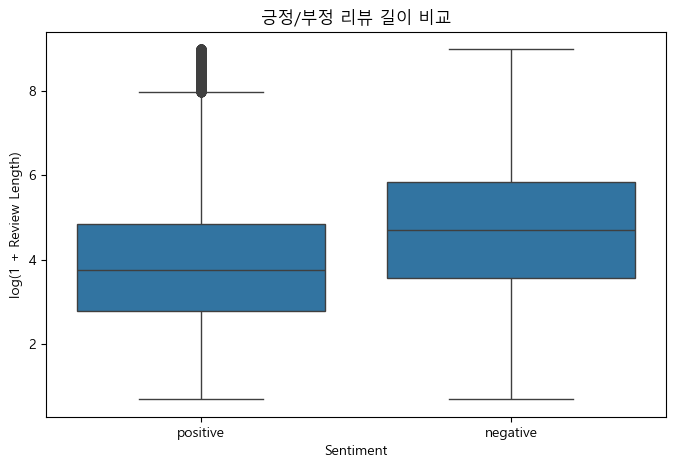

In [ ]:
reviews["log_review_length"] = np.log1p(reviews["review_length"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_review_length"
)

plt.title("긍정/부정 리뷰 길이 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Review Length)")
plt.show()

플레이 타임을 전처리

In [ ]:
reviews["playtime_hours"] = (reviews["playtime_forever_hours"] / 60).round(2)

reviews[["playtime_forever_hours", "playtime_hours"]].head()

,playtime_forever_hours,playtime_hours
0,2.600000,0.04
1,6.583333,0.11
2,0.716667,0.01
3,8.000000,0.13
4,1.400000,0.02


긍정과 부정별 플레이타임 비교

In [ ]:
playtime_summary = (
    reviews.groupby("sentiment")["playtime_hours"]
    .describe()
)

playtime_summary

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,17364.0,0.253222,0.758986,0.0,0.02,0.08,0.26,43.92
positive,218489.0,0.553114,2.116996,0.0,0.14,0.33,0.63,505.32


중앙값만 보기

In [ ]:
reviews.groupby("sentiment")["playtime_hours"].median()

sentiment
negative    0.08
positive    0.33
Name: playtime_hours, dtype: float64

플레이 타임의 극단값이 너무 커서 로그변환 진행 후 시각화

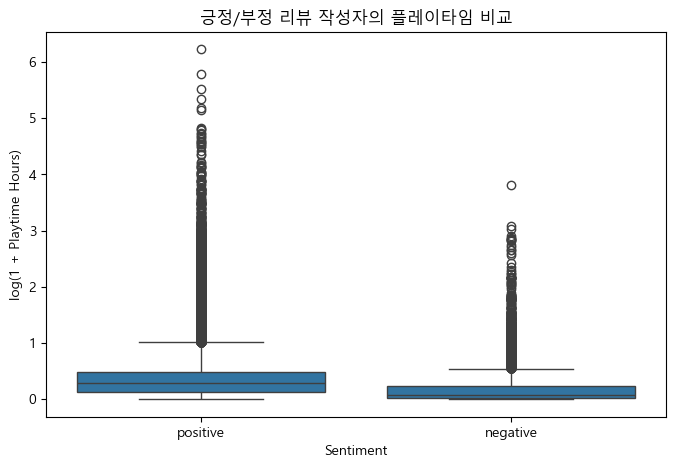

In [ ]:
reviews["log_playtime_hours"] = np.log1p(reviews["playtime_hours"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_playtime_hours"
)

plt.title("긍정/부정 리뷰 작성자의 플레이타임 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Playtime Hours)")
plt.show()

언어의 분포 확인

In [ ]:
language_summary = (
    reviews["language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "review_count"]
language_summary.head(20)

,language,review_count
0,english,148915
1,russian,16952
2,schinese,14781
3,spanish,13980
4,brazilian,7832
5,german,6309
6,french,5240
7,polish,3415
8,koreana,3240
9,latam,2717


시각화

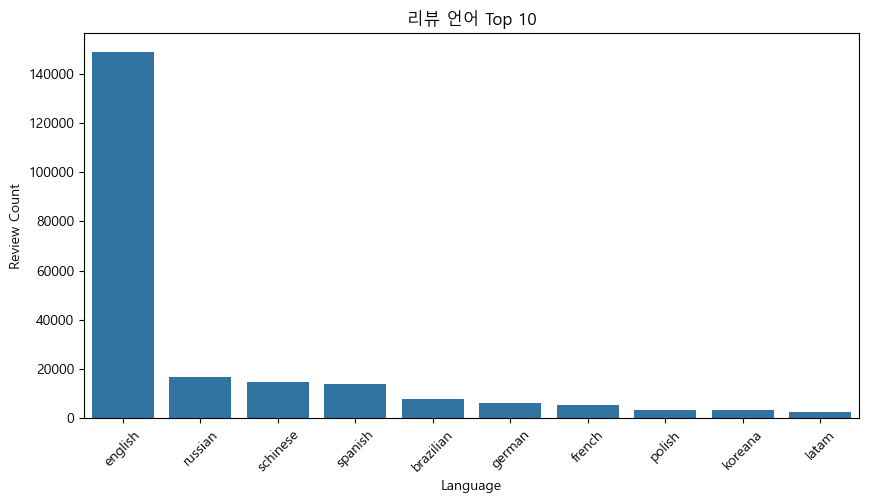

In [ ]:
top_lang = reviews["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_lang.index,
    y=top_lang.values
)

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

언어별 긍정율 비율

In [ ]:
lang_sentiment = (
    reviews.groupby("language")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .sort_values("review_count", ascending=False)
)

lang_sentiment.head(20)

,review_count,positive_ratio
language,,
english,148915,0.941248
russian,16952,0.926616
schinese,14781,0.783912
spanish,13980,0.949928
brazilian,7832,0.957993
german,6309,0.898241
french,5240,0.905725
polish,3415,0.950512
koreana,3240,0.887037


언어는 너무다양하기때문에 30개이상의 리뷰가 있는 리뷰만봐보자

In [ ]:
lang_sentiment_30 = lang_sentiment[
    lang_sentiment["review_count"] >= 30
].copy()

lang_sentiment_30.sort_values("positive_ratio", ascending=False)

,review_count,positive_ratio
language,,
vietnamese,49,0.979592
brazilian,7832,0.957993
portuguese,279,0.956989
finnish,327,0.951070
greek,81,0.950617
polish,3415,0.950512
spanish,13980,0.949928
latam,2717,0.944792
italian,1215,0.941564


시각화

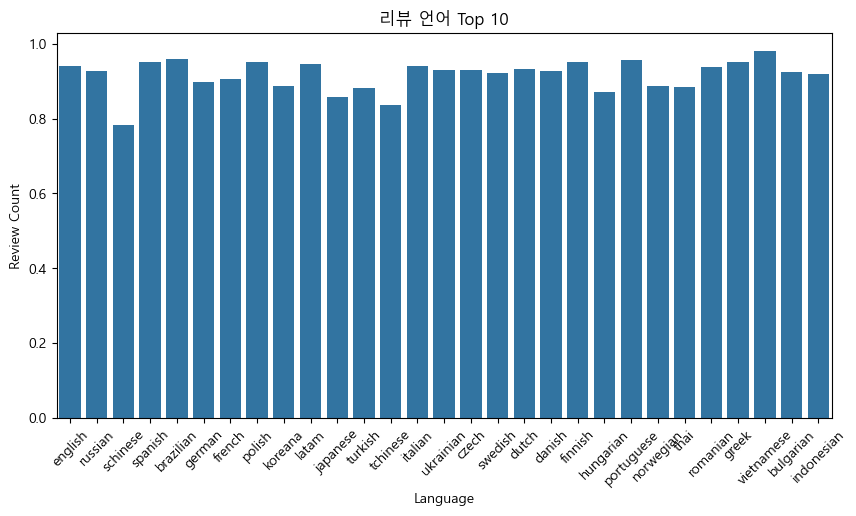

In [ ]:
pos_ratio = lang_sentiment_30

plt.figure(figsize=(10, 5))
sns.barplot(data = pos_ratio , x = 'language',y = 'positive_ratio')

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

시간칼럼 변화

In [ ]:
reviews["created_date"] = pd.to_datetime(
    reviews["timestamp_created"],
    unit="s",
    errors="coerce"
)

reviews["created_month"] = reviews["created_date"].dt.to_period("M").astype(str)

reviews[["timestamp_created", "created_date", "created_month"]].head()

,timestamp_created,created_date,created_month
0,1442518373,2015-09-17 19:32:53,2015-09
1,1442599803,2015-09-18 18:10:03,2015-09
2,1442604265,2015-09-18 19:24:25,2015-09
3,1442612819,2015-09-18 21:46:59,2015-09
4,1442623099,2015-09-19 00:38:19,2015-09


In [ ]:
monthly_review = (
    reviews.groupby("created_month")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .reset_index()
)

monthly_review.head()

,created_month,review_count,positive_ratio
0,2015-09,19,0.684211
1,2015-10,9,0.555556
2,2015-11,3,0.666667
3,2015-12,5,0.600000
4,2016-01,3,0.666667


전체 리뷰 중 긍정 리뷰 비율은 약 78.9%로 나타났다.
부정 리뷰는 긍정 리뷰보다 리뷰 길이 중앙값이 길었고, 이는 불만 유저가 더 구체적인 문제를 작성했을 가능성을 보여준다.
플레이타임 기준으로는 부정 리뷰 작성자의 중앙 플레이타임이 더 높았다.
언어별로는 영어 리뷰가 가장 많았으며, 리뷰 수 30개 이상 언어 중 스페인 언어의 긍정 비율이 가장 높았다.

## 긍정리뷰와 부정리뷰 키워드 분석

영어로 작성된 리뷰로 먼저 확인작업 진행

전처리

In [ ]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

print(reviews_en.shape)
reviews_en[["review", "sentiment"]].head()

(148915, 30)


,review,sentiment
0,"Right, \n\nSo it's finally here. I've been fol...",positive
2,It was very difficult to play through the tuto...,negative
3,This game has so much potential. I have been f...,positive
4,I'm recommending this game because of what I'v...,positive
5,This is an exceptional bit of fun. Be warned ...,positive


In [ ]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

reviews_en["clean_review"] = reviews_en["review"].apply(clean_text)

reviews_en[["review", "clean_review"]].head()

,review,clean_review
0,"Right, \n\nSo it's finally here. I've been fol...",right so it s finally here i ve been following...
2,It was very difficult to play through the tuto...,it was very difficult to play through the tuto...
3,This game has so much potential. I have been f...,this game has so much potential i have been fo...
4,I'm recommending this game because of what I'v...,i m recommending this game because of what i v...
5,This is an exceptional bit of fun. Be warned ...,this is an exceptional bit of fun be warned it...


불용어 제거후 단어 빈도 확인

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer

# stop_words = [
#     # 기본 영어
#     "the","and","is","it","to","of","a","in","for","this","that","you",
#     "with","on","as","are","was","but","be","have","not","so","if","at",
#     "by","an","or","from","they","we","he","she","them","his","her","our",
#     "their","its","who","what","which","when","where","why","how",

#     # 대명사/지시어
#     "i","me","my","mine","your","yours","our","ours","their","theirs",
#     "him","herself","himself","ourselves","themselves",

#     # 일반 동사 (의미 약함)
#     "get","got","make","made","go","went","take","took","use","used",
#     "try","tried","give","gave","come","came","want","wanted",
#     "see","seen","look","looked","find","found","think","thought",
#     "know","knew","keep","kept","put","set","run","ran",

#     # 시간/수량
#     "one","two","three","first","second","many","much","lot","lots",
#     "few","some","any","every","each","all",
#     "time","times","hour","hours","day","days","week","weeks","month","months",

#     # 게임 리뷰 흔한 단어
#     "game","games","play","playing","played","player","players",
#     "thing","things","way","something","anything","everything",
#     "stuff","part","parts","experience",

#     # 평가 표현 (너무 일반적)
#     "good","bad","great","nice","fun","boring","awesome","amazing",
#     "love","like","liked","hate","dislike","recommend","recommended",
#     "best","worst","better","worse","cool","enjoy","enjoyed",

#     # 강도/정도 표현
#     "really","very","pretty","quite","too","so","just","even","still",
#     "well","almost","maybe","probably","definitely","actually",

#     # 부정/축약형
#     "im","ive","dont","didnt","cant","couldnt","would","should",
#     "wasnt","werent","isnt","arent","doesnt","hadnt","hasnt","havent",

#     # 기타 잡단어
#     "yes","no","ok","okay","uh","um",
#     "etc","etc.","lol","haha","yeah","yep",

#     # 리뷰에서 흔히 나오는 무의미 단어
#     "edit","update","review","reviews","steam","pc","version","patch",
#     "dev","developer","devs","support","thanks",

#     # 숫자/단위 관련
#     "10","20","30","100","1000",
#     "fps","gb","mb"
# ]
    

# def get_top_words(data, sentiment_value, n=30):
#     text_data = data[data["sentiment"] == sentiment_value]["clean_review"]
    
#     vectorizer = CountVectorizer(
#         stop_words=stop_words,
#         min_df=3
#     )
    
#     word_matrix = vectorizer.fit_transform(text_data)
    
#     word_counts = word_matrix.sum(axis=0).A1
#     words = vectorizer.get_feature_names_out()
    
#     result = pd.DataFrame({
#         "word": words,
#         "count": word_counts
#     }).sort_values("count", ascending=False)
    
#     return result.head(n)

# positive_words = get_top_words(reviews_en, "positive", 30)
# negative_words = get_top_words(reviews_en, "negative", 30)

# positive_words

불용어를 아무리 추가해도 노이즈 자꾸 나옴 
방식변경 => TF-IDF방식
많이나오는 단어는 중요할 수 있어 가산점을 주지만 모든 곳에서 많이나온다면 의미가 없다고 판단하여 페널티를줘서
진짜 중요한 단어를 뽑아오는 기법

한개 단어만 보면 노이즈가 많을 가능성이 높기때문에 2단어 조합으로 보기

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
def get_tfidf_terms(data, sentiment_value, n=50):
    texts = data[data["sentiment"] == sentiment_value]["clean_review"]

    tfidf = TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.7,
        ngram_range=(2, 2) #(1,1) → 단어 1개
                           #(2,2) → 단어 2개
                           #(1,2) → 단어 + 2단어 둘 다
    )

    X = tfidf.fit_transform(texts)

    result = pd.DataFrame({
        "term": tfidf.get_feature_names_out(),
        "score": X.sum(axis=0).A1
    }).sort_values("score", ascending=False)

    return result.head(n)

positive_tfidf = get_tfidf_terms(reviews_en, "positive")
negative_tfidf = get_tfidf_terms(reviews_en, "negative")

positive_tfidf

,term,score
36027,good game,1736.222791
37383,great game,1033.985362
81080,toby fox,936.072279
5047,best game,917.484635
29144,fun game,795.839838
51414,love game,671.790995
228,absolute cinema,666.052869
16619,deltarune today,625.009215
31147,game good,546.953864
31946,game play,531.297563


In [ ]:
negative_tfidf

,term,score
3184,feels like,60.553741
4078,game just,58.610689
4958,golf friends,56.683109
5013,good game,55.535509
6835,like game,50.456855
2574,early access,50.023234
3118,feel like,46.489101
8682,play game,45.965465
9650,recommend game,44.411917
4253,game play,43.488771


good game, fun game등 노이즈가 많기 때문에 이런 단어 제거용 리스트 만들고 적용

추가적으로 게임타이틀을 쓰는 경우도 있기때문에 게임타이틀도 제거 진행

In [ ]:
noise_bigrams = [
    "good game", "fun game", "great game", "game fun", "game great",
    "game play", "love game", "game good", "recommend game",
    "game really", "play game", "like game", "game just",
    "game like", "really fun", "really good", "little game",
    "game love", "games like", "game ve", "playing game",
    "pretty good", "game lot", "buy game", "game amazing",
    "best game", "game feels", "game game", "game worth",
    "played game", "felt like", "feel like", "feels like",
    "game recommend", "amazing game", "ve played"
]
game_title_terms = [
    "duck detective",
    "luck landlord",
    "cod zombies"
]

bigram_df_clean = positive_tfidf[
    ~positive_tfidf["term"].isin(noise_bigrams)
].copy()

bigram_df_clean = bigram_df_clean[
    ~bigram_df_clean["term"].isin(game_title_terms)
].copy()

bigram_df_clean.head(50)

,term,score
81080,toby fox,936.072279
228,absolute cinema,666.052869
16619,deltarune today,625.009215
16624,deltarune tomorrow,388.335511
51399,love fishing,387.309558
61334,play friends,386.520452
18852,dig hole,363.628493
18941,digging hole,342.507895
77654,survival horror,328.798524
16248,delta rune,315.814950


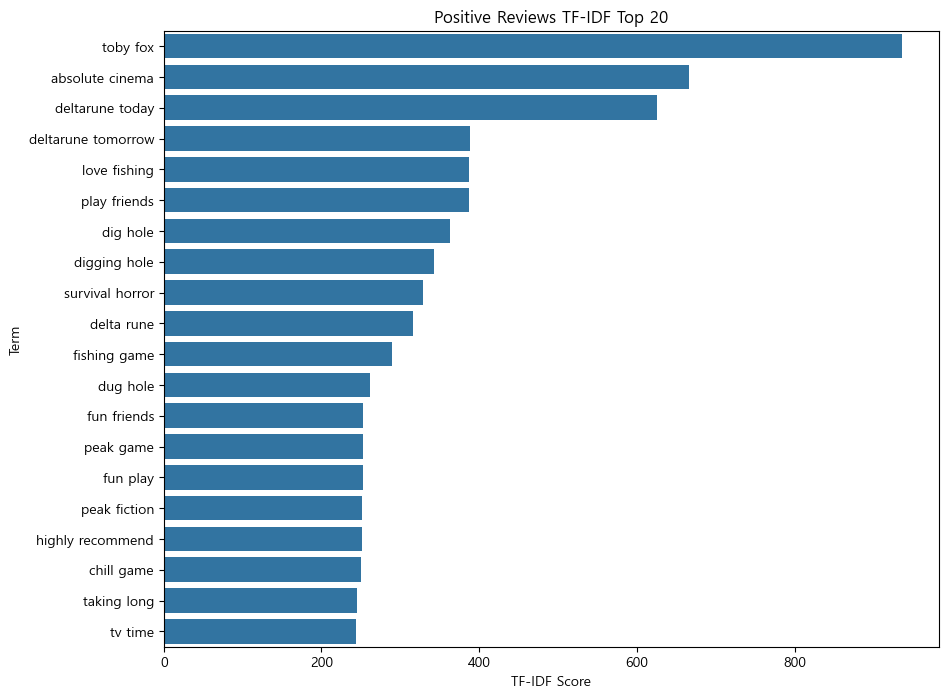

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=bigram_df_clean.head(20),
    x="score",
    y="term"
)

plt.title("Positive Reviews TF-IDF Top 20")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.show()

In [ ]:
issue_keywords = {
    "bug_crash": ["bug", "bugs", "crash", "crashes", "crashed", "glitch", "broken"],
    "performance": ["lag", "fps", "performance", "optimization", "stutter", "slow"],
    "server_online": ["server", "servers", "disconnect", "online", "multiplayer", "matchmaking"],
    "price_value": ["price", "expensive", "worth", "refund", "money", "paid"],
    "repetitive_content": ["repetitive", "grind", "content", "boring", "same"],
    "control_ux": ["control", "controls", "ui", "menu", "tutorial"],
    "balance_difficulty": ["balance", "difficulty", "hard", "unfair", "easy"]
}

In [ ]:
def tag_issues(text):
    text = str(text).lower()
    tags = []

    for category, keywords in issue_keywords.items():
        if any(keyword in text for keyword in keywords):
            tags.append(category)

    return tags

negative_reviews = reviews_en[reviews_en["sentiment"] == "negative"].copy()

negative_reviews["issue_tags"] = negative_reviews["clean_review"].apply(tag_issues)

negative_reviews[["review", "issue_tags"]].head()

,review,issue_tags
2,It was very difficult to play through the tuto...,"[bug_crash, control_ux]"
7,"Game crashes 75% of the time, labels are all w...",[bug_crash]
12,This GAME IS TOTAL GARBAGE and a SCAM It shoul...,"[bug_crash, price_value, repetitive_content, c..."
21,i can see the possiablitiy of this game being ...,"[bug_crash, price_value]"
25,2025. The full release last year was my only h...,[control_ux]


In [ ]:
from collections import Counter

issue_counter = Counter()

for tags in negative_reviews["issue_tags"]:
    issue_counter.update(tags)

issue_summary = pd.DataFrame(
    issue_counter.items(),
    columns=["issue_category", "count"]
).sort_values("count", ascending=False)

issue_summary

,issue_category,count
1,control_ux,2230
2,price_value,1678
3,repetitive_content,1550
5,balance_difficulty,1242
0,bug_crash,1117
4,performance,662
6,server_online,250


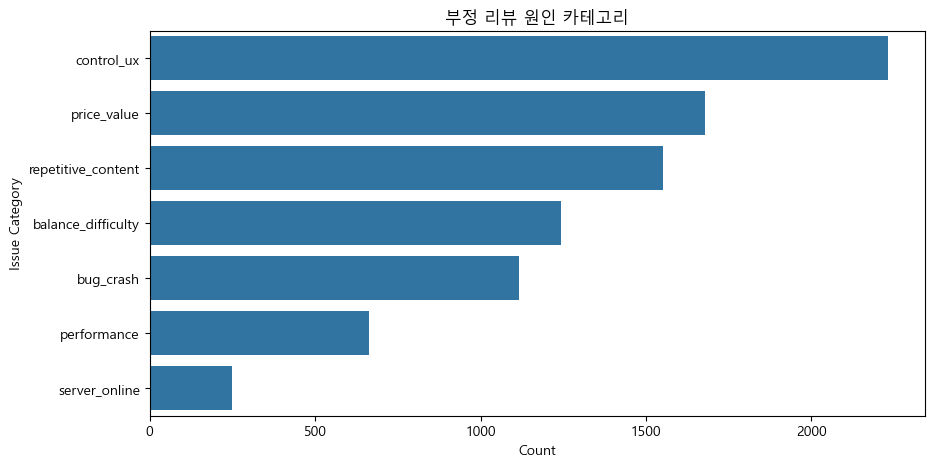

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=issue_summary,
    x="count",
    y="issue_category"
)

plt.title("부정 리뷰 원인 카테고리")
plt.xlabel("Count")
plt.ylabel("Issue Category")
plt.show()